In [12]:
"""
GMM-Based Price Distribution Detection with Normality Verification

Detects price distribution regimes using Gaussian Mixture Models (GMM).
Identifies which distribution the current price belongs to and verifies
that the distribution is actually normal.

Algorithm:
1. Use GMM to find how many distributions exist
2. Identify which component contains the current price
3. Extract price levels belonging to that component
4. Test if those levels are normally distributed
5. Keep expanding window until normality is confirmed

Usage:
    python scripts/curr.py --symbol TSLA --timeframe 1h --step 0.1

Copy-paste friendly: All code can be copied into a Jupyter notebook cell.
"""

# =============================================================================
# IMPORTS
# =============================================================================
import sys
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Add parent directory for imports (for notebook)
sys.path.insert(0, str(Path.cwd().parent))
from src.data_loader import DataLoader


# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def generate_price_levels(df: pd.DataFrame, step: float = 0.1) -> np.ndarray:
    """
    Generate discrete price levels from candle high-low ranges.

    For each candle, generates price points from low to high in increments of `step`.
    Returns prices in chronological order (oldest first).
    """
    all_prices = []
    for _, row in df.iterrows():
        prices = np.arange(row['low'], row['high'] + step, step)
        all_prices.extend(prices)
    return np.array(all_prices)


# =============================================================================
# NORMALITY TESTING FUNCTIONS
# =============================================================================

def run_normality_tests(data: np.ndarray, alpha: float = 0.05) -> dict:
    """
    Run multiple normality tests on the data.

    Tests: Shapiro-Wilk, D'Agostino-Pearson, Anderson-Darling, Jarque-Bera

    Args:
        data: Array of values to test
        alpha: Significance level (default 0.05)

    Returns:
        Dictionary with test results
    """
    results = {}

    # Need minimum data points
    if len(data) < 20:
        return {
            'shapiro_wilk': {'is_normal': None, 'note': 'Insufficient data'},
            'dagostino_pearson': {'is_normal': None, 'note': 'Insufficient data'},
            'anderson_darling': {'is_normal': None, 'note': 'Insufficient data'},
            'jarque_bera': {'is_normal': None, 'note': 'Insufficient data'},
        }

    # Shapiro-Wilk test (sample if data is too large)
    if len(data) > 5000:
        sample_data = np.random.choice(data, size=5000, replace=False)
        shapiro_note = " (sampled 5000 points)"
    else:
        sample_data = data
        shapiro_note = ""

    stat, p = stats.shapiro(sample_data)
    results['shapiro_wilk'] = {
        'statistic': stat,
        'p_value': p,
        'is_normal': p > alpha,
        'note': shapiro_note
    }

    # D'Agostino-Pearson test
    stat, p = stats.normaltest(data)
    results['dagostino_pearson'] = {
        'statistic': stat,
        'p_value': p,
        'is_normal': p > alpha
    }

    # Anderson-Darling test
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FutureWarning)
        result = stats.anderson(data, dist='norm')
    critical_5pct = result.critical_values[2]
    results['anderson_darling'] = {
        'statistic': result.statistic,
        'critical_value_5pct': critical_5pct,
        'is_normal': result.statistic < critical_5pct
    }

    # Jarque-Bera test
    stat, p = stats.jarque_bera(data)
    results['jarque_bera'] = {
        'statistic': stat,
        'p_value': p,
        'is_normal': p > alpha
    }

    return results


def is_distribution_normal(test_results: dict, min_passing: int = 2) -> tuple:
    """
    Determine if the data is normally distributed based on test results.

    Args:
        test_results: Dictionary from run_normality_tests()
        min_passing: Minimum number of tests that must pass (default 2)

    Returns:
        Tuple of (is_normal: bool, tests_passed: int, total_tests: int)
    """
    passed = sum(1 for t in test_results.values() if t.get('is_normal') is True)
    total = sum(1 for t in test_results.values() if t.get('is_normal') is not None)
    return passed >= min_passing, passed, total


# =============================================================================
# GMM FUNCTIONS
# =============================================================================

def find_optimal_components(data: np.ndarray, max_components: int = 3) -> tuple:
    """
    Find optimal number of GMM components using BIC.

    Returns:
        Tuple of (best_n_components, bic_scores, best_gmm_model)
    """
    data = data.reshape(-1, 1)
    bics = []
    models = []

    for n in range(1, max_components + 1):
        gmm = GaussianMixture(n_components=n, random_state=42, n_init=3)
        gmm.fit(data)
        bics.append(gmm.bic(data))
        models.append(gmm)

    best_n = np.argmin(bics) + 1
    return best_n, bics, models[best_n - 1]


def get_component_prices(price_levels: np.ndarray, gmm, component: int) -> np.ndarray:
    """
    Extract price levels that belong to a specific GMM component.

    Uses soft assignment (probability > 0.5) to assign prices to components.

    Args:
        price_levels: Array of all price levels
        gmm: Fitted GMM model
        component: Component index to extract

    Returns:
        Array of price levels belonging to this component
    """
    data = price_levels.reshape(-1, 1)
    probas = gmm.predict_proba(data)
    mask = probas[:, component] > 0.5
    return price_levels[mask]


def get_price_distribution(price_levels: np.ndarray, current_price: float,
                           n_components: int = None) -> dict:
    """
    Fit GMM and identify which distribution the current price belongs to.
    Also extracts prices from the current price's component for normality testing.
    """
    data = price_levels.reshape(-1, 1)

    # Auto-detect components if not specified
    if n_components is None:
        n_components, bics, gmm = find_optimal_components(data)
    else:
        gmm = GaussianMixture(n_components=n_components, random_state=42, n_init=3)
        gmm.fit(data)
        bics = None

    # Classify current price
    component = gmm.predict([[current_price]])[0]
    proba = gmm.predict_proba([[current_price]])[0]

    # Get component parameters
    mean = gmm.means_[component][0]
    std = np.sqrt(gmm.covariances_[component][0][0])

    # Extract prices belonging to this component
    component_prices = get_component_prices(price_levels, gmm, component)

    return {
        'n_components': n_components,
        'current_component': component,
        'current_mean': mean,
        'current_std': std,
        'confidence': proba[component],
        'all_means': gmm.means_.flatten(),
        'all_stds': np.sqrt(gmm.covariances_.flatten()),
        'weights': gmm.weights_,
        'gmm': gmm,
        'bics': bics,
        'component_prices': component_prices  # Prices for normality testing
    }


# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_gmm_distributions(price_levels: np.ndarray, result: dict,
                           current_price: float, normality_results: dict = None):
    """
    Visualize GMM components and highlight current price's distribution.
    Shows normality test results if provided.
    """
    n_plots = 3 if normality_results else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))

    # Left: Histogram with GMM components
    axes[0].hist(price_levels, bins=100, density=True, alpha=0.5,
                 color='gray', label='All Data')

    x = np.linspace(price_levels.min(), price_levels.max(), 1000)

    colors = ['blue', 'red', 'green']
    for i in range(result['n_components']):
        mean = result['all_means'][i]
        std = result['all_stds'][i]
        weight = result['weights'][i]

        component_pdf = weight * stats.norm.pdf(x, mean, std)
        label = f'Comp {i}: mu={mean:.1f}, std={std:.1f}'

        if i == result['current_component']:
            label += ' <- CURRENT'
            axes[0].plot(x, component_pdf, color=colors[i % len(colors)],
                        linewidth=3, label=label)
        else:
            axes[0].plot(x, component_pdf, color=colors[i % len(colors)],
                        linewidth=1.5, linestyle='--', label=label)

    axes[0].axvline(current_price, color='black', linestyle=':', linewidth=2,
                    label=f'Current: {current_price:.1f}')
    axes[0].set_xlabel('Price Level')
    axes[0].set_ylabel('Density')
    axes[0].set_title(f'GMM: {result["n_components"]} Component(s) Detected')
    axes[0].legend(fontsize=8)

    # Middle: BIC comparison
    if result['bics'] is not None:
        n_range = range(1, len(result['bics']) + 1)
        colors_bar = ['green' if i == result['n_components'] else 'gray' for i in n_range]
        axes[1].bar(n_range, result['bics'], color=colors_bar)
        axes[1].set_xlabel('Number of Components')
        axes[1].set_ylabel('BIC (lower is better)')
        axes[1].set_title('Model Selection via BIC')
        axes[1].set_xticks(list(n_range))
    else:
        axes[1].text(0.5, 0.5, 'BIC not computed',
                     ha='center', va='center', transform=axes[1].transAxes)

    # Right: Normality test results (if provided)
    if normality_results and n_plots == 3:
        # Q-Q plot for component prices
        component_prices = result['component_prices']
        if len(component_prices) >= 20:
            stats.probplot(component_prices, dist="norm", plot=axes[2])

            # Add normality verdict
            is_normal, passed, total = is_distribution_normal(normality_results)
            verdict = "NORMAL" if is_normal else "NOT NORMAL"
            color = 'green' if is_normal else 'red'
            axes[2].set_title(f'Q-Q Plot: {verdict} ({passed}/{total} tests passed)',
                             color=color)
        else:
            axes[2].text(0.5, 0.5, f'Insufficient data\n({len(component_prices)} points)',
                        ha='center', va='center', transform=axes[2].transAxes)
            axes[2].set_title('Q-Q Plot')

    plt.tight_layout()
    plt.show()


def print_normality_results(test_results: dict):
    """Print formatted normality test results."""
    print("\nNormality Test Results:")
    print("-" * 40)
    for name, result in test_results.items():
        if result.get('is_normal') is None:
            status = "N/A"
        else:
            status = "PASS" if result['is_normal'] else "FAIL"

        if 'p_value' in result and result['p_value'] is not None:
            print(f"  {name}: {status} (p={result['p_value']:.4f})")
        elif 'statistic' in result and result['statistic'] is not None:
            print(f"  {name}: {status} (stat={result['statistic']:.4f})")
        else:
            print(f"  {name}: {result.get('note', 'N/A')}")
    print("-" * 40)


# =============================================================================
# MAIN DETECTION LOOP
# =============================================================================

def run_gmm_detection(symbol: str = 'TSLA', timeframe: str = '1h',
                      step: float = 0.1, initial_window: int = 30,
                      max_iterations: int = 200, window_increment: int = 5,
                      min_tests_passing: int = 2, alpha: float = 0.05):
    """
    Run GMM distribution detection loop with normality verification.

    The algorithm:
    1. Start with initial_window candles
    2. Use GMM to find distribution components
    3. Identify which component contains the current price
    4. Extract price levels from that component
    5. Run normality tests on those prices
    6. If normal: stop and return results
    7. If not normal: expand window and repeat

    Args:
        symbol: Stock symbol
        timeframe: Data timeframe
        step: Price level increment
        initial_window: Starting window size (candles)
        max_iterations: Maximum iterations before stopping
        window_increment: Candles to add each iteration
        min_tests_passing: Minimum normality tests that must pass
        alpha: Significance level for normality tests

    Returns:
        Tuple of (result_dict, normality_results, current_price, final_window_size)
        or None if data loading fails
    """
    # Load data
    print(f"Loading {symbol} {timeframe} data...")
    loader = DataLoader(symbol=symbol)
    df = loader.get_data(timeframe=timeframe)

    if df is None or len(df) == 0:
        print(f"Error: No data found for {symbol} {timeframe}")
        return None

    print(f"Loaded {len(df)} candles")

    current_price = df['close'].iloc[-1]
    print(f"Current price: {current_price:.2f}")
    print(f"Searching for normal distribution regime...")
    print(f"Criteria: {min_tests_passing}/4 normality tests must pass (alpha={alpha})\n")

    counter = 0
    window_size = initial_window

    while counter < max_iterations and window_size <= len(df):
        # Get subset of most recent candles
        subset = df.tail(window_size)
        price_levels = generate_price_levels(subset, step=step)
        price_levels = price_levels[::-1]

        # Need minimum data for meaningful analysis
        if len(price_levels) < 100:
            counter += 1
            window_size += window_increment
            continue

        # Fit GMM and get component containing current price
        result = get_price_distribution(price_levels, current_price)

        # Get prices from current price's component
        component_prices = result['component_prices']

        # Need enough component prices for normality tests
        if len(component_prices) < 20:
            if counter % 20 == 0:
                print(f"Iter {counter}: Window={window_size}, "
                      f"component has only {len(component_prices)} points (need 20+)")
            counter += 1
            window_size += window_increment
            continue

        # Run normality tests on the component prices
        normality_results = run_normality_tests(component_prices, alpha=alpha)
        is_normal, passed, total = is_distribution_normal(normality_results, min_tests_passing)

        if is_normal:
            print(f"\nFound NORMAL distribution at iteration {counter}!")
            print(f"  Window: {window_size} candles")
            print(f"  Components detected: {result['n_components']}")
            print(f"  Current price ({current_price:.2f}) is in component {result['current_component']}")
            print(f"  Component mean: {result['current_mean']:.2f}")
            print(f"  Component std:  {result['current_std']:.2f}")
            print(f"  Component prices: {len(component_prices)} points")
            print(f"  Normality: {passed}/{total} tests passed")

            return result, normality_results, current_price, window_size

        # Progress logging
        if counter % 20 == 0:
            print(f"Iter {counter}: Window={window_size}, "
                  f"{result['n_components']} comp, "
                  f"normality={passed}/{total}")

        counter += 1
        window_size += window_increment

    # Max iterations or data exhausted
    print(f"\nSearch stopped at iteration {counter}")
    print(f"Final window: {window_size} candles")
    print(f"Normality not achieved ({passed}/{total} tests)")

    return result, normality_results, current_price, window_size

In [13]:
# =============================================================================
# HORIZONTAL PRICE ZONE VISUALIZATION
# =============================================================================

from matplotlib.gridspec import GridSpec

def plot_price_zones_horizontal(df: pd.DataFrame, result: dict, current_price: float,
                                 price_levels: np.ndarray = None):
    """
    Plot price chart with GMM-detected zones as horizontal bands,
    plus a marginal histogram on the right showing price distribution.
    
    Args:
        df: DataFrame with OHLCV data (must have 'time' and 'close' columns)
        result: Dictionary from get_price_distribution()
        current_price: Current price to highlight
        price_levels: Optional array of price levels for histogram
    """
    fig = plt.figure(figsize=(18, 8))
    gs = GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)

    ax_main = fig.add_subplot(gs[0])  # Main price chart
    ax_hist = fig.add_subplot(gs[1], sharey=ax_main)  # Side histogram
    
    # --- Main plot (left) ---
    ax_main.plot(df['time'], df['close'], 'k-', linewidth=0.8, alpha=0.9, label='Price')
    
    # Draw horizontal bands for each GMM component
    colors = ['blue', 'red', 'green', 'purple', 'orange']
    
    for i in range(result['n_components']):
        mean = result['all_means'][i]
        std = result['all_stds'][i]
        
        # Band = mean ± 2*std (95% of the distribution)
        lower = mean - 2 * std
        upper = mean + 2 * std
        
        is_current = (i == result['current_component'])
        alpha = 0.3 if is_current else 0.15
        linewidth = 2 if is_current else 1
        
        ax_main.axhspan(lower, upper, alpha=alpha, color=colors[i % len(colors)],
                   label=f'Zone {i+1}: ${mean:.0f} ± ${std:.0f}')
        ax_main.axhline(mean, color=colors[i % len(colors)], linestyle='--',
                   linewidth=linewidth, alpha=0.8)
    
    # Mark current price
    ax_main.axhline(current_price, color='black', linestyle=':', linewidth=2,
               label=f'Current: ${current_price:.0f}')
    
    ax_main.set_xlabel('Time')
    ax_main.set_ylabel('Price ($)')
    ax_main.set_title(f'TSLA Price Zones (GMM: {result["n_components"]} zones detected)')
    ax_main.legend(loc='upper left')
    ax_main.grid(True, alpha=0.3)

    # --- Side histogram (right) ---
    if price_levels is not None:
        # Histogram of price levels (horizontal orientation)
        ax_hist.hist(price_levels, bins=50, orientation='horizontal',
                     alpha=0.5, color='gray', density=True)

        # Overlay GMM component curves
        y_range = np.linspace(price_levels.min(), price_levels.max(), 200)
        for i in range(result['n_components']):
            mean = result['all_means'][i]
            std = result['all_stds'][i]
            weight = result['weights'][i]
            pdf = weight * stats.norm.pdf(y_range, mean, std)
            ax_hist.plot(pdf, y_range, color=colors[i % len(colors)], linewidth=2)

    ax_hist.axhline(current_price, color='black', linestyle=':', linewidth=2)
    ax_hist.set_xlabel('Density')
    ax_hist.tick_params(axis='y', labelleft=False)  # Hide y-labels (shared with main)
    ax_hist.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def is_uncharted(price: float, result: dict, threshold_std: float = 2.5) -> bool:
    """
    Check if price is in uncharted territory (not within any zone).
    Returns True if price is more than threshold_std away from all zone means.
    
    Args:
        price: Price to check
        result: Dictionary from get_price_distribution()
        threshold_std: Number of standard deviations to consider "within zone"
        
    Returns:
        True if price is in uncharted territory, False otherwise
    """
    for i in range(result['n_components']):
        mean = result['all_means'][i]
        std = result['all_stds'][i]
        if abs(price - mean) < threshold_std * std:
            return False
    return True


def get_zone_info(price: float, result: dict) -> dict:
    """
    Get detailed information about which zone a price belongs to.
    
    Args:
        price: Price to analyze
        result: Dictionary from get_price_distribution()
        
    Returns:
        Dictionary with zone information
    """
    zone_distances = []
    
    for i in range(result['n_components']):
        mean = result['all_means'][i]
        std = result['all_stds'][i]
        distance_std = abs(price - mean) / std
        zone_distances.append({
            'zone': i + 1,
            'mean': mean,
            'std': std,
            'distance_std': distance_std,
            'within_2std': distance_std < 2.0,
            'within_2.5std': distance_std < 2.5
        })
    
    # Sort by distance
    zone_distances.sort(key=lambda x: x['distance_std'])
    
    return {
        'price': price,
        'nearest_zone': zone_distances[0],
        'all_zones': zone_distances,
        'is_uncharted': is_uncharted(price, result)
    }

📂 Loaded 5000 candles from cache: /Users/nikolastsalidis/Desktop/smart-money-concepts/data/tsla/tsla_15min.csv
PRICE ZONE DETECTION SUMMARY
Analyzed: 1000 candles
Current Price: $439.80
Zones Detected: 3

Zone 1: $424 - $464 (mean: $444, std: $10) <-- CURRENT
Zone 2: $468 - $495 (mean: $482, std: $7)
Zone 3: $386 - $436 (mean: $411, std: $12)

Price $439.80 is in Zone 1 (0.5 std from mean)


/var/folders/38/5ydk0_ln1b11mn8vdpwqgfyw0000gn/T/ipykernel_49374/2944308920.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


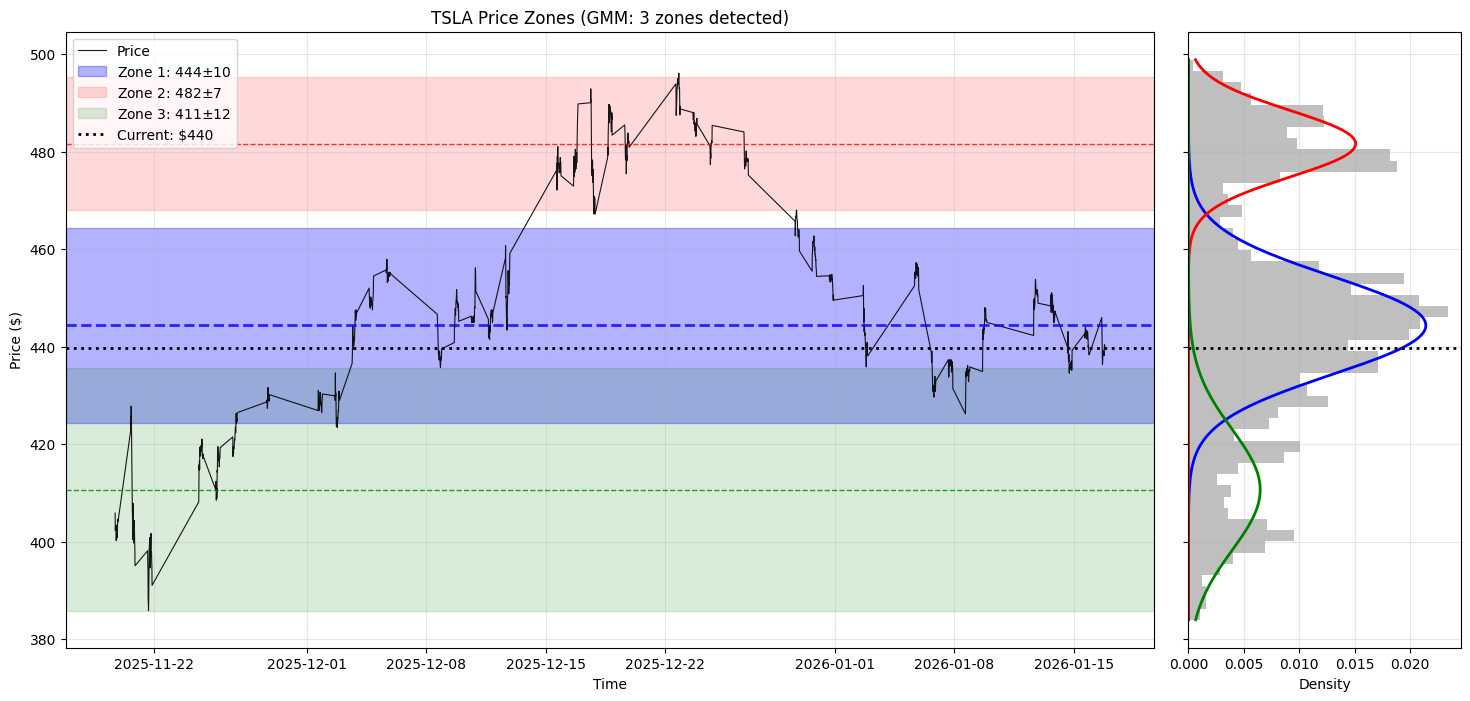

In [23]:
# =============================================================================
# FULL WORKFLOW: HORIZONTAL PRICE ZONES
# =============================================================================
# This cell demonstrates the complete workflow for detecting and visualizing
# price zones as horizontal bands

# Load data
loader = DataLoader(symbol='TSLA')
df = loader.get_data('15min', force_refresh=False)
current_price = df['close'].iloc[-1]

# Use recent data for zone detection (adjustable window)
window_size = 1000  # Number of candles to analyze
df_subset = df.tail(window_size)

# Generate price levels and fit GMM
price_levels = generate_price_levels(df_subset, step=0.1)
result = get_price_distribution(price_levels, current_price)

# Print zone summary
print("=" * 50)
print("PRICE ZONE DETECTION SUMMARY")
print("=" * 50)
print(f"Analyzed: {window_size} candles")
print(f"Current Price: ${current_price:.2f}")
print(f"Zones Detected: {result['n_components']}")
print()

for i in range(result['n_components']):
    mean = result['all_means'][i]
    std = result['all_stds'][i]
    lower = mean - 2 * std
    upper = mean + 2 * std
    is_current = i == result['current_component']
    marker = " <-- CURRENT" if is_current else ""
    print(f"Zone {i+1}: ${lower:.0f} - ${upper:.0f} (mean: ${mean:.0f}, std: ${std:.0f}){marker}")

print()

# Check uncharted territory
zone_info = get_zone_info(current_price, result)
if zone_info['is_uncharted']:
    print(f"ALERT: Price ${current_price:.2f} is in UNCHARTED TERRITORY!")
    print(f"Nearest zone is Zone {zone_info['nearest_zone']['zone']} "
          f"({zone_info['nearest_zone']['distance_std']:.1f} std away)")
else:
    nearest = zone_info['nearest_zone']
    print(f"Price ${current_price:.2f} is in Zone {nearest['zone']} "
          f"({nearest['distance_std']:.1f} std from mean)")

print("=" * 50)

# Visualize horizontal price zones with side histogram
plot_price_zones_horizontal(df_subset, result, current_price, price_levels)